# Bivariate Analysis

*Bivariate data* refers to a dataset where each observation is associated with two different variables. The goal of analyzing bivariate data is to understand the relationship or association between these two variables.

- Detects whether the relationship is positive, negative or non-existent.
- Correlation measures the strength and direction of the relationship (range: -1 to +1).
- Visualization tools like scatter plots and regression lines show the pattern of change clearly.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
path_data = Path('../../data')

In [10]:
sns.set_context(
    "notebook",
    font_scale=1.5,
    rc={
        "lines.linewidth": 2.5
    }
)

## Example: Hybrid Cars Dataset

In [11]:
hybrid = pd.read_csv(path_data / 'hybrid.csv')
hybrid

,vehicle,year,msrp,acceleration,mpg,class
0,Prius (1st Gen),1997,24509.74,7.46,41.26,Compact
1,Tino,2000,35354.97,8.20,54.10,Compact
2,Prius (2nd Gen),2000,26832.25,7.97,45.23,Compact
3,Insight,2000,18936.41,9.52,53.00,Two Seater
4,Civic (1st Gen),2001,25833.38,7.04,47.04,Compact
...,...,...,...,...,...,...
148,S400,2013,92350.00,13.89,21.00,Large
149,Prius Plug-in,2013,32000.00,9.17,50.00,Midsize
150,C-Max Energi Plug-in,2013,32950.00,11.76,43.00,Midsize
151,Fusion Energi Plug-in,2013,38700.00,11.76,43.00,Midsize


The table `hybrid` contains data on hybrid passenger cars sold in the United States from 1997 to 2013. The data were adapted from the online data archive of [Prof. Larry Winner](http://www.stat.ufl.edu/%7Ewinner/) of the University of Florida. The columns:

- `vehicle`: model of the car
- `year`: year of manufacture
- `msrp`: manufacturer's suggested retail price in 2013 dollars
- `acceleration`: acceleration rate in km per hour per second
- `mpg`: fuel econonmy in miles per gallon
- `class`: the model's class.

### Relationship 1: Price vs. Acceleration

The graph below is a **scatter plot** of `msrp` *versus* `acceleration`. That means:

- `msrp` is plotted on the vertical axis
- `accelaration` on the horizontal

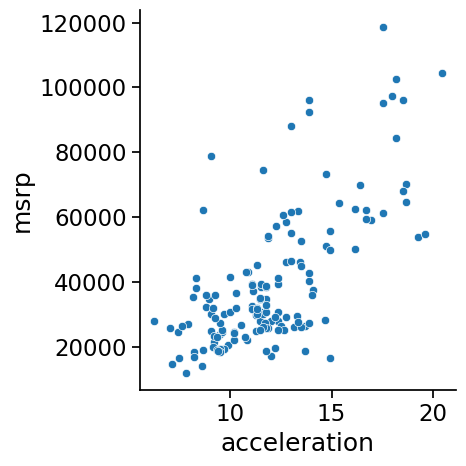

In [12]:
sns.relplot(
    data=hybrid, x='acceleration', y='msrp',
    kind='scatter',
    height=5,
);

**Notice the positive association**. The scatter of points is **sloping upwards**, indicating that cars with greater acceleration tended to cost more, on average; conversely, the cars that cost more tended to have greater acceleration on average. 

The `lmplot` can actuall draw a *Regression Line* making it easier to see the relationship between the two numerical variables:

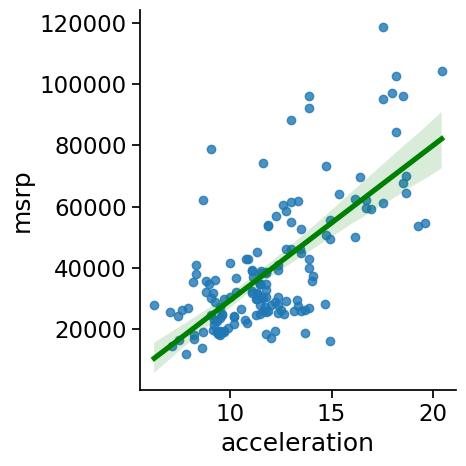

In [13]:
sns.lmplot(
    data=hybrid, x='acceleration', y='msrp',
    height=5,
    line_kws={'color': 'green'}
);

- Question: **What is the shaded region around the line?**
- Answer: **Confidence Interval** (CI). The further away the line is from the dataset, the narrow the shaded region is, indicating less certainty.

### Relationship 2: Price vs Efficiency

The scatter diagram of MSRP versus mileage shows **a negative association**. Hybrid cars with higher mileage tended to cost less, on average. This seems surprising till you consider that **cars that accelerate fast tend to be less fuel efficient and have lower mileage**. As the previous scatter plot showed, those were also the cars that tended to cost more. 

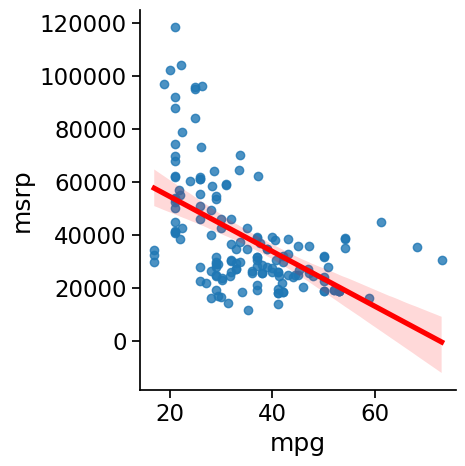

In [14]:
sns.lmplot(
    data=hybrid, x='mpg', y='msrp',
    height=5,
    line_kws={'color': 'red'}
);

Along with the negative association, the scatter diagram of price versus efficiency shows a non-linear relation between the two variables. The points appear to be clustered around a curve, **not around a straight line**. 

### Relationship 3: Price vs Efficiency (SUV)

**If we restrict the data just to the SUV class**, however, the association between price and efficiency is still **negative but the relation appears to be more linear**.

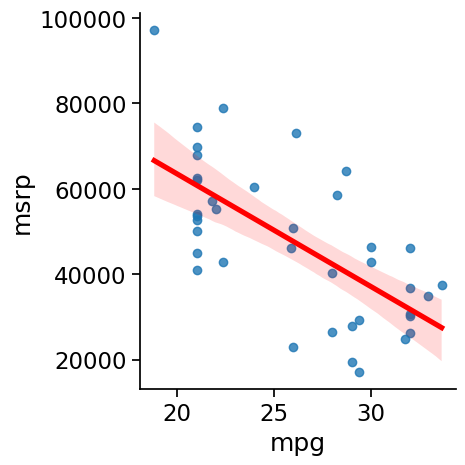

In [15]:
suv = hybrid[hybrid['class'] == 'SUV'].copy()

sns.lmplot(
    data=suv, x='mpg', y='msrp',
    height=5,
    line_kws={'color': 'red'}
);

### Relationship 4: Price vs Acceleration (SUV)

The relation between the price and acceleration of SUV's also shows a **linear trend, but with a positive slope**.

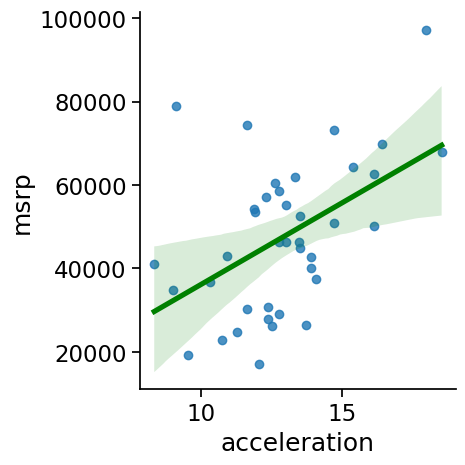

In [16]:
sns.lmplot(
    data=suv, x='acceleration', y='msrp',
    height=5,
    line_kws={'color': 'green'}
);

## The Correlation Coefficient

**Correlation** (a.k.a *Pearson correlation coefficient* or linear association) which always takes values between `-1` and `1`, describes the **strength and direction** of the linear relationship between two variables. We denote the correlation by $r$.

Graphically, **it measures how clustered the scatter diagram is around a straight line**.

Figure 7.10 shows eight plots and their corresponding correlations.

- Only when the relationship is perfectly linear is the correlation either -1 or +1.
- If the relationship is strong and positive, the correlation will be near +1.
- If it is strong and negative, it will be near -1.
- If there is no apparent linear relationship between the variables, then the correlation will be near zero.

![](../../assets/correlation_coefficient.png)

### Interactive: copy-modify-run

**Try**: call the function below with different values of `r` to generate data that fits that correlation coefficient.

In [17]:
# Source: https://inferentialthinking.com/chapters/15/1/correlation/
def r_scatter(r):
    "Generate a scatter plot with a correlation approximately r"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    g = sns.relplot(x=x, y=y, kind='scatter', height=5)
    g.ax.set_xlim(-4, 4)
    g.ax.set_ylim(-4, 4)

Change the following value to see different outputs:

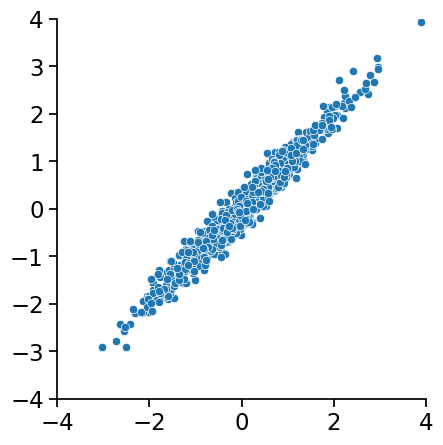

In [18]:
r_scatter(0.98) # <<<--- CHANGE THIS

### Definition: Math

The formula for correlation is:

$$
r = \frac{1}{n-1} \sum_{i=1}^{n} \left( \frac{x_i-\bar{x}}{s_x} \right) \left( \frac{y_i-\bar{y}}{s_y} \right)
$$

The terms inside the parentheses are exactly the definitions of $z$-scores for $x$ and $y$:

- $z_{x,i} = \frac{x_i-\bar{x}}{s_x}$
- $z_{y,i} = \frac{y_i-\bar{y}}{s_y}$

So, the formula simplifies to:

$$
r = \frac{\sum z_x z_y}{n-1}
$$

In essence, **correlation $r$ is the average of the products of the two variables, when both variables are measured in standard units.**

## Application on the Hybrid Cars Dataset

In [19]:
rel1_corr, _ = stats.pearsonr(hybrid['acceleration'], hybrid['msrp'])
rel2_corr, _ = stats.pearsonr(hybrid['mpg'], hybrid['msrp'])
rel3_corr, _ = stats.pearsonr(suv['mpg'], suv['msrp'])
rel4_corr, _ = stats.pearsonr(suv['acceleration'], suv['msrp'])

Let's lay down all the plots from above, and show their correlation as text on the plot:

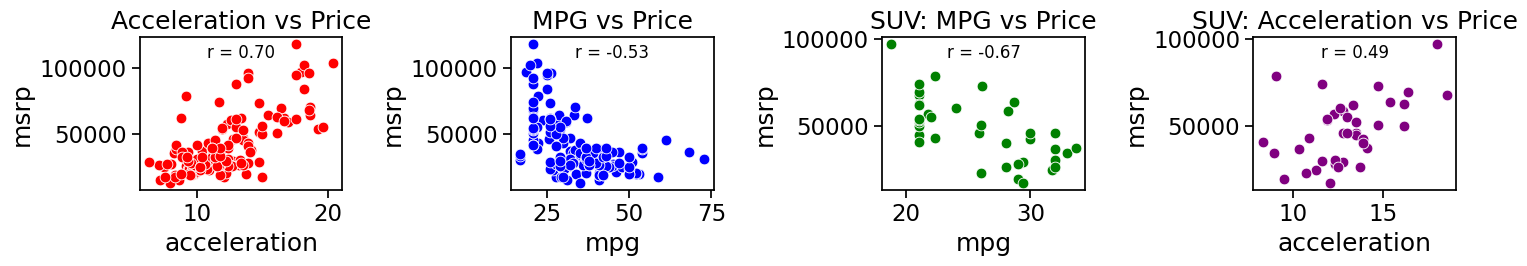

In [20]:
# | code-fold: true
# | echo: false

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(15, 3))

# Relationship 1: Price vs. Acceleration (Hybrid)
sns.scatterplot(x='acceleration', y='msrp', data=hybrid, s=60, color='red', ax=ax[0])
ax[0].set_title('Acceleration vs Price')
ax[0].text(0.5, 0.9, f'r = {rel1_corr:.2f}', ha='center', va='center', 
           transform=ax[0].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 2: Price vs Efficiency (Hybrid)
sns.scatterplot(x='mpg', y='msrp', data=hybrid, s=60, color='blue', ax=ax[1])
ax[1].set_title('MPG vs Price')
ax[1].text(0.5, 0.9, f'r = {rel2_corr:.2f}', ha='center', va='center', 
           transform=ax[1].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 3: Price vs Efficiency (SUV)
sns.scatterplot(x='mpg', y='msrp', data=suv, s=60, color='green', ax=ax[2])
ax[2].set_title('SUV: MPG vs Price')
ax[2].text(0.5, 0.9, f'r = {rel3_corr:.2f}', ha='center', va='center', 
           transform=ax[2].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


# Relationship 4: Price vs Acceleration (SUV)
sns.scatterplot(x='acceleration', y='msrp', data=suv, s=60, color='purple', ax=ax[3])
ax[3].set_title('SUV: Acceleration vs Price')
ax[3].text(0.5, 0.9, f'r = {rel4_corr:.2f}', ha='center', va='center', 
           transform=ax[3].transAxes, fontsize=12, color='black', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))


plt.tight_layout()
plt.show()

These values confirm what we had observed: 

- There is a **negative** association between price and efficiency, whereas the association between price and acceleration is **positive**.
- The linear relation between price and acceleration is a **little weaker** (correlation about `0.5`) **than between** price and mileage (correlation about `-0.67`). 

### `sns.pairplot`

Plot pairwise relationships in a dataset:

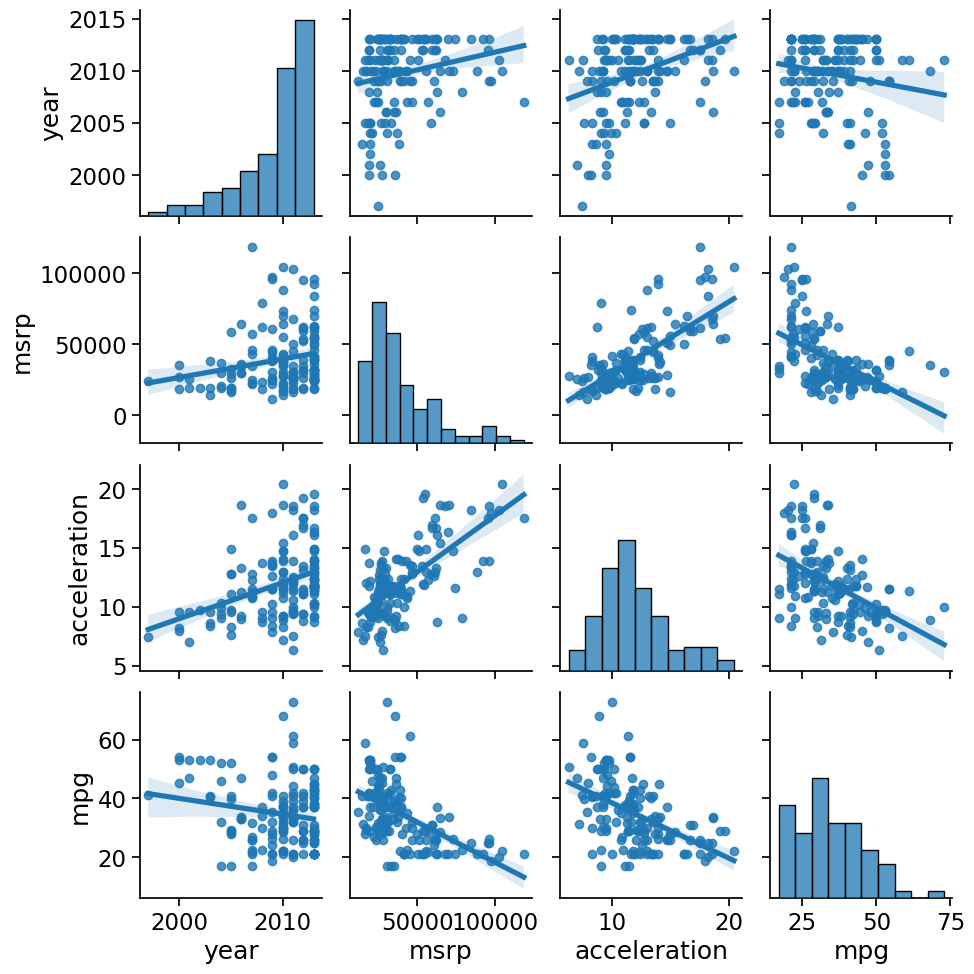

In [21]:
sns.pairplot(hybrid, kind='reg')

By default, this function will create a grid of Axes such that each numeric variable in `data` will by shared across the y-axes across a single row and the x-axes across a single column.

The diagonal plots are treated differently: a univariate distribution plot is drawn to show the marginal distribution of the data in each column.

## Correlation Coefficient is Unitless

One important aspect of the correlation is that it’s unitless. The following figure shows the relationship between weights and heights of `507` physically active individuals:

- Figure a: weight is measured in kilograms (`kg`) and height in centimeters (`cm`).
- Figure b: weight has been converted to pounds (`lbs`) and height to inches (`in`)

![](../../assets/correlation_unitless.png)

## Correlation is not causation

Even if we get $r = 1$ or $r = -1$, it would be too early to say that $x$ causes $y$.

A **Confounding Variable** (or "confounder") is an outside influence that changes the relationship between an independent and a dependent variable.

### Example 1: Fire and Fire Fighters

Correlation between **more fire fighters** at a scene with greater property damage. It would be a logical fallacy to conclude that the reaction is what caused the action.

1. Actor: fire
2. Action: property damage
3. Reaction: fire fighters

### Example 2: Chocolate Consumption & Nobel Prizes

In 2012, a [paper](http://www.biostat.jhsph.edu/courses/bio621/misc/Chocolate%20consumption%20cognitive%20function%20and%20nobel%20laurates%20%28NEJM%29.pdf) in the respected New England Journal of Medicine examined the relation between chocolate consumption and Nobel Prizes in a group of countries. The [Scientific American](http://blogs.scientificamerican.com/the-curious-wavefunction/chocolate-consumption-and-nobel-prizes-a-bizarre-juxtaposition-if-there-ever-was-one/) responded seriously whereas [others](http://www.reuters.com/article/2012/10/10/us-eat-chocolate-win-the-nobel-prize-idUSBRE8991MS20121010#vFdfFkbPVlilSjsB.97) were more relaxed. You are welcome to make your own decision! The following graph, provided in the paper, should motivate you to go and take a look.

![](../../assets/chocoNobel.png)

### Example 3: Weight and Math

A correlation can be found with high coefficient between `weight` and `score` in math. However, it is not causal.

Older children are heavier than younger children. However, they are also better at math since their **brain is more developed**.

### Example 4: Species to Bill Depth and Length

In [22]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


If you look at the whole dataset, there is a **negative** correlation between `bill_depth` and `bill_length`:

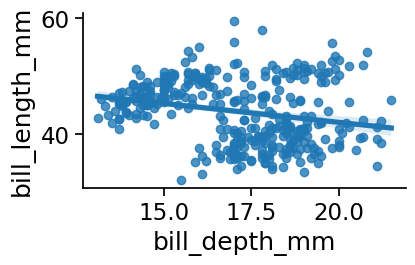

In [23]:
sns.lmplot(
    data=penguins,
    x="bill_depth_mm", y="bill_length_mm",
    aspect=1.5, height=3
);

**The Confounder:** When you color-code by `species`, the correlation within each group is actually **positive**:

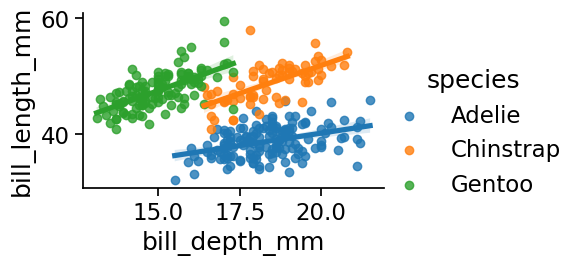

In [24]:
sns.lmplot(
    data=penguins,
    x="bill_depth_mm", y="bill_length_mm", hue="species",
    aspect=1.5, height=3
);

The presence of confounders helps explain why correlation does not imply causation, and why careful study design and analytical methods (such as randomization, statistical adjustment, or causal diagrams) are required to distinguish causal effects from spurious associations.

### Non-examples: Body Mass and Flipper Length

If you plot Body Mass against Flipper Length, you see a strong, **positive correlation** in the general population. As penguins get larger, their flippers get longer.

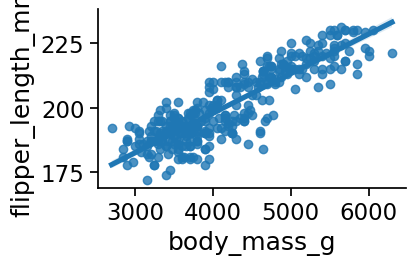

In [25]:
sns.lmplot(
    data=penguins,
    x="body_mass_g", y="flipper_length_mm",
    aspect=1.5, height=3
);

Perhaps `sex` is a confounder? To find out, let's color-code and plot it's regression line:

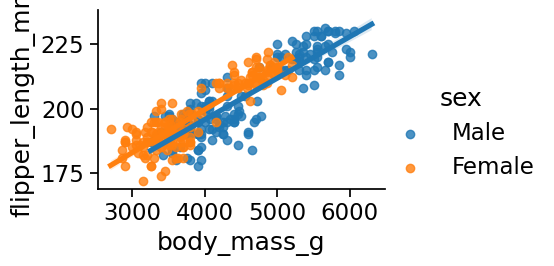

In [26]:
sns.lmplot(
    data=penguins,
    x="body_mass_g", y="flipper_length_mm", hue="sex",
    aspect=1.5, height=3
);

Observation: correlation is maintained.

Maybe `species` is a confounder?

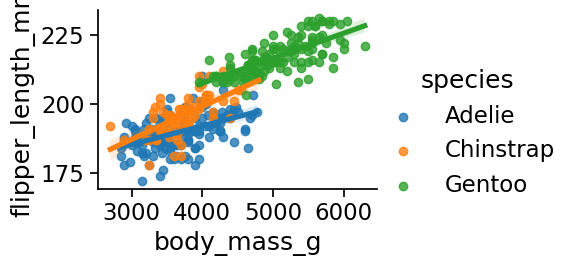

In [27]:
sns.lmplot(
    data=penguins,
    x="body_mass_g", y="flipper_length_mm", hue="species",
    aspect=1.5, height=3
);

Observation: correlation is maintained.

Neither `sex` nor `species` were confounding to the relationship between flipper length and body mass. As such, **we are more convinced that their relationship is direct and isn't caused by something else**.

### How to establish causality?

Interested in learning more about causal inference? checkout [chapter 2: Study Design | Intro to Modern Statistics by Mine Çetinkaya-Rundel and Johanna Hardin](https://openintro-ims.netlify.app/data-design).

---

## Association

**Association** measures the relationship between two categorical variables.

This is done in two steps:

1. To qualify the association as being **significant**, we'll be using ther Chi-square test
2. To quantify the **strength** of association, we'll be using Cramer's V

## Example 1: Titanic Survival and Class

People in higher `pclass` on the titanic may have had access to life boats or may have been simply treated better. Is there an association between that and whether they `survived` or not?

Let's find out..

In [28]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


Create a contingency table to analyze the association between `survived` and `pclass`:

In [29]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    normalize='index' # Percentage
)
contingency_table

survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In [30]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    normalize='index' # Percentage
)
contingency_table

survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


Using a `heatmap` to add color and intensity makes it easier to read and compare:

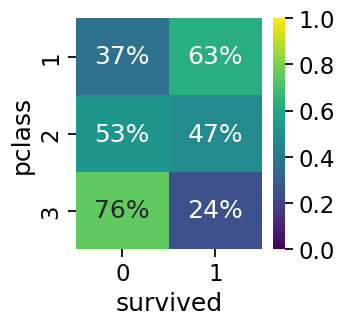

In [31]:
plt.figure(figsize=(3, 3))
sns.heatmap(
    contingency_table,
    annot=True, cmap="viridis", fmt=".0%", vmin=0, vmax=1
);

### Step 1: Chi-square Test ($\chi^2$)

- The **Chi-squared test** is used to test for **association between two categorical variables**.
- However, it doesn't quantify how strong this association is.

Moreover, the test needs the **unnormalized** contingency table:

In [32]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    # normalize='index'
)
contingency_table

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


Now let's apply the test: 

In [33]:
from scipy.stats import chi2_contingency

# significance level
alpha = 0.05

# Run the Chi-Square Test
chi2_stat, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

print("\n--- Chi-Square Test Results ---")
print(f"P-value: {p_value:.2e}")  # Scientific notation is useful here
print("significant!" if p_value <= alpha else "not enough evidence")


--- Chi-Square Test Results ---
P-value: 4.55e-23
significant!


Always check the p-value of your Chi-square test first. If the p-value is not significant (usually $p > 0.05$), the association is likely due to chance, and interpreting Cramér's V becomes moot. In our case, the $p < 0.05$ and hence we proceed..

We do not care about the `chi2_stat` and `expected_frequencies`, but, we will need the **Degrees of Freedom** (`dof = min(n_rows, n_cols)`) in interpreting Cramer's V test result. 

### Step 2: Calculate Cramer's V

In [34]:
from scipy.stats.contingency import association

# Calculate Cramér's V
cramers_v = association(
    observed=contingency_table,
    method='cramer',
    correction=True
)

print(f"Cramér's V: {cramers_v:.2f}")

Cramér's V: 0.34


### Step 3: Interpreting the results

Cramér's V ranges from **0 to 1**. It does not indicate direction (since categorical data has no inherent order), only magnitude.

- **0**: No association between the variables.
- **1**: Perfect association (knowing the value of one variable allows you to perfectly predict the other).

Cohen (1988) provided general benchmarks for what constitutes a "small," "medium," or "large" effect, and can be generalized in the following snippet of code:

In [35]:
def interpret_cramers_v(v: float, dof: int) -> str:
    benchmarks = {
        "Small": 0.1 / np.sqrt(dof),
        "Medium": 0.3 / np.sqrt(dof),
        "Large": 0.5 / np.sqrt(dof)
    }
    
    if v < benchmarks["Small"]:
        return "Negligible"
    elif v < benchmarks["Medium"]:
        return "Small"
    elif v < benchmarks["Large"]:
        return "Medium"
    else:
        return "Large"

In [36]:
print(f"Degrees of Freedom: {dof}")
print("        Effect size:", interpret_cramers_v(cramers_v, dof))

Degrees of Freedom: 2
        Effect size: Medium


## Example 2: Sex and Occupation

Are there gender differences between preferences of occupations that both men and women choose to go for?

[Adult Dataset Source | UCI](https://archive.ics.uci.edu/dataset/2/adult).

In [37]:
# Data Source: 
adult = pd.read_csv('../../data/adult.csv')
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [38]:
# Drop rows with missing occupation data for a clean test
adult = adult.dropna(subset=['occupation', 'sex'])

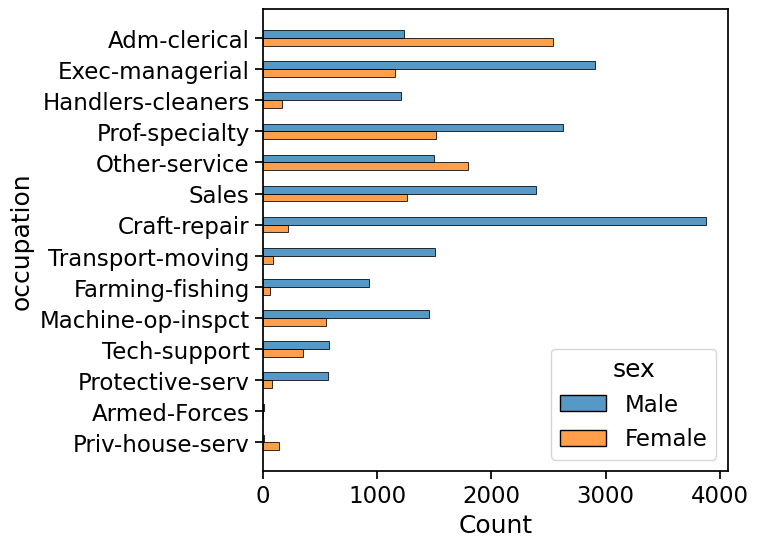

In [39]:
plt.figure(figsize=(6, 6))
sns.histplot(
    adult,
    y='occupation', hue='sex',
    discrete=True, shrink=0.5,
    
    multiple='dodge', # Adjacent bars
);

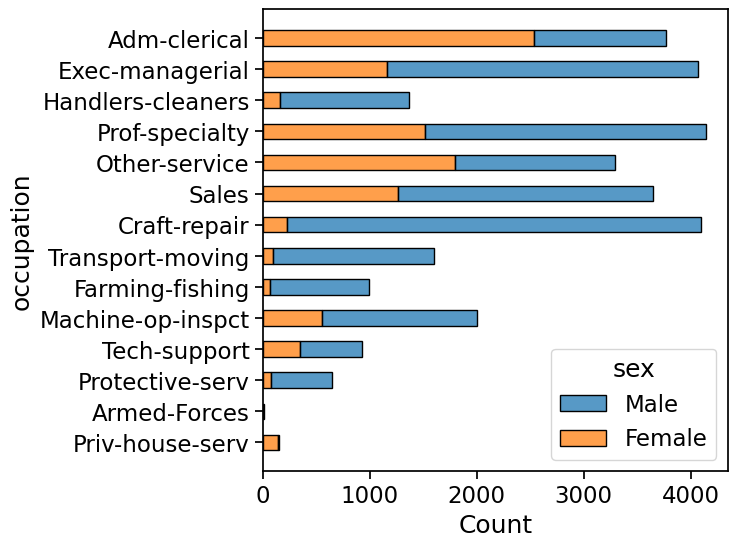

In [40]:
plt.figure(figsize=(6, 6))
sns.histplot(
    adult,
    y='occupation', hue='sex',
    discrete=True, shrink=0.5,
    
    multiple='stack', # Stacked bars
);

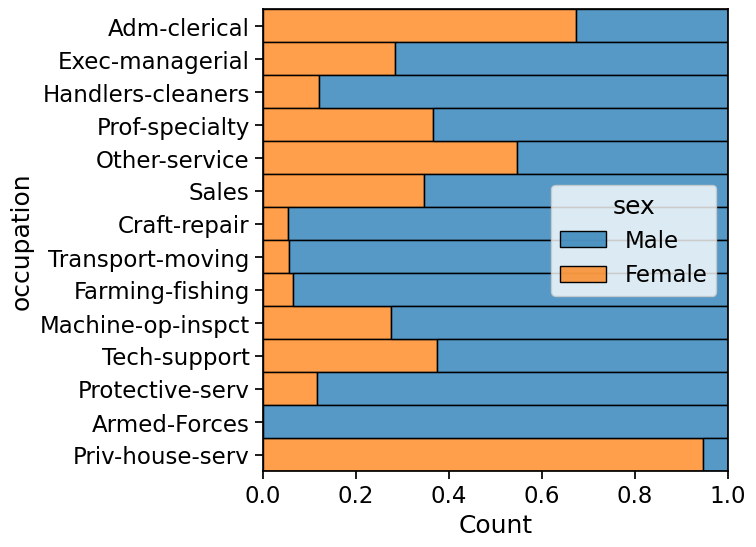

In [41]:
plt.figure(figsize=(6, 6))
sns.histplot(
    adult,
    y='occupation', hue='sex', discrete=True,
    multiple='fill', # Complementary bars
);

Create a contingency table to analyze the association between `sex` and `occupation`:

In [42]:
adult_contingency_table = pd.crosstab(
    index=adult['occupation'],
    columns=adult['sex'],
    normalize='index'
)
adult_contingency_table

sex,Female,Male
occupation,,
Adm-clerical,0.672944,0.327056
Armed-Forces,0.000000,1.000000
Craft-repair,0.054160,0.945840
Exec-managerial,0.285047,0.714953
Farming-fishing,0.065392,0.934608
Handlers-cleaners,0.119708,0.880292
Machine-op-inspct,0.274725,0.725275
Other-service,0.546282,0.453718
Priv-house-serv,0.946309,0.053691


Using a `heatmap` to add color and intensity makes it easier to read and compare:

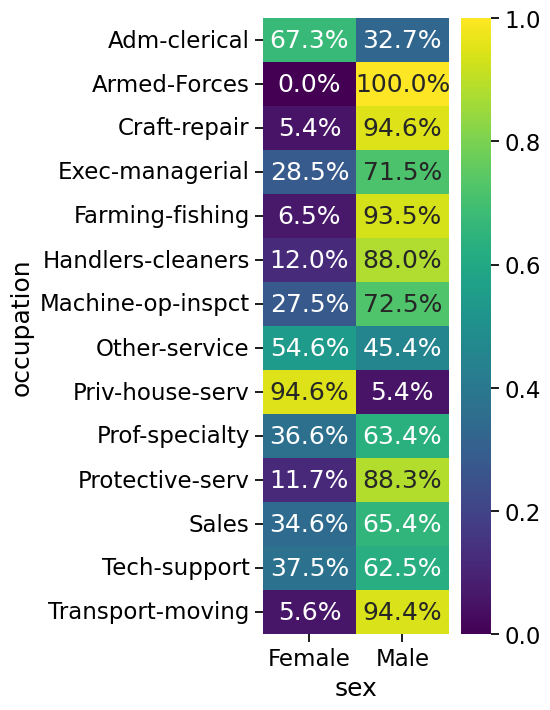

In [43]:
plt.figure(figsize=(3, 8))
sns.heatmap(
    adult_contingency_table,
    annot=True, cmap="viridis", fmt=".1%", vmin=0, vmax=1
);

# The End